# Previsão de Performance e Bem-estar de Alunos

## Problema
Dado um conjunto de dados de 5000 registos de alunos com 21 features, desenvolvemos dois modelos:
1. **Classificação**: Prever o nível de Burnout [Baixo | Médio | Alto]
2. **Regressão**: Prever a nota máxima que um aluno consegue obter (Exam Score)

## Abordagem
- **Divisão**: Learning Set (80%) para model selection + Test Set (20%) para avaliação final
- **Pré-processamento**: Pipeline com imputação, escalagem e encoding
- **Validação**: Cross-validation (5-fold)
- **Modelos**: Decision Tree (classificação) e Linear Regression (regressão)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate, train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif, 
                                       RFE, SequentialFeatureSelector)

## 0. Carregar Dados e Preparar

In [12]:
# Carregar o dataset
df = pd.read_csv('../Dados_Projeto/student_records_missing.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColunas do dataset:")
print(df.columns.tolist())

# Definir as features (componentes preditivas)
numeric_features = ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 
                     'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score', 'age']
nominal_features = ['gender', 'academic_level']
ordinal_features = ['internet_quality']
binary_features = ['part_time_job', 'upcoming_deadline']

# Definir todos os targets (coisas que queremos prever)
all_targets = ['focus_index', 'burnout_level', 'productivity_score', 'exam_score']

# Remover todos os targets e student_id (que é apenas um ID)
X = df.drop(columns=all_targets + ['student_id'])

# Targets para cada tarefa
y_exam_score = df['exam_score']  # Regressão: prever a nota contínua
y_burnout_continuous = df['burnout_level']  # Será transformado em 3 classes

print(f"\nX shape: {X.shape}")
print(f"Features totais: {X.shape[1]}")
print(f"Exam Score (regressão): {y_exam_score.shape}")
print(f"Burnout Level (será classificação): {y_burnout_continuous.shape}")

Dataset shape: (5000, 21)

Colunas do dataset:
['student_id', 'age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']

X shape: (5000, 16)
Features totais: 16
Exam Score (regressão): (5000,)
Burnout Level (será classificação): (5000,)



Burnout Level - Quantis para 3 classes:
Quantil 1/3: 39.00
Quantil 2/3: 51.67

Distribuição das classes de Burnout:
0    1667
1    1666
2    1667
Name: count, dtype: int64
Percentagens: 0    33.3
1    33.3
2    33.3
Name: count, dtype: float64


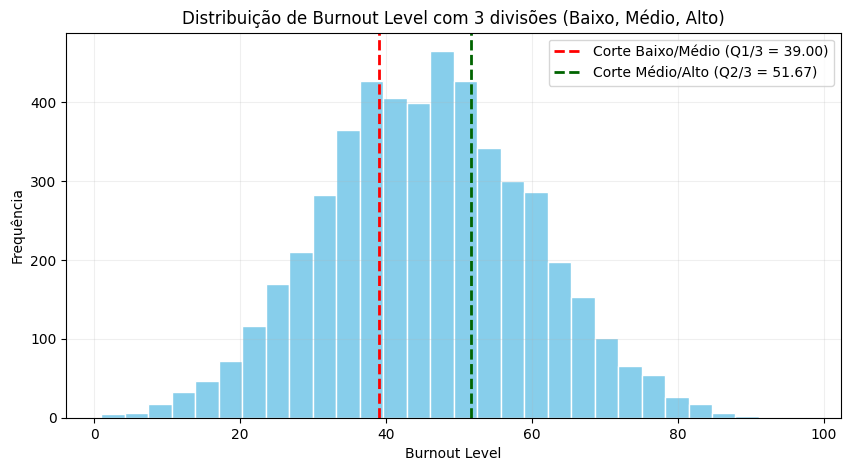

In [13]:
quantiles = y_burnout_continuous.quantile([1/3, 2/3])
q1 = quantiles.iloc[0]
q2 = quantiles.iloc[1]

print(f"\nBurnout Level - Quantis para 3 classes:")
print(f"Quantil 1/3: {q1:.2f}")
print(f"Quantil 2/3: {q2:.2f}")

y_burnout_class = pd.cut(
    y_burnout_continuous,
    bins=[y_burnout_continuous.min() - 1, q1, q2, y_burnout_continuous.max() + 1],
    labels=['Baixo', 'Médio', 'Alto'],
    include_lowest=True
)

y_burnout_class_encoded = pd.Categorical(y_burnout_class).codes

print(f"\nDistribuição das classes de Burnout:")
print(pd.Series(y_burnout_class_encoded).value_counts().sort_index())
print(f"Percentagens: {(pd.Series(y_burnout_class_encoded).value_counts().sort_index() / len(y_burnout_class_encoded) * 100).round(1)}")

plt.figure(figsize=(10, 5))
plt.hist(y_burnout_continuous, bins=30, color='skyblue', edgecolor='white')
plt.axvline(q1, color='red', linestyle='--', linewidth=2, label=f'Corte Baixo/Médio (Q1/3 = {q1:.2f})')
plt.axvline(q2, color='darkgreen', linestyle='--', linewidth=2, label=f'Corte Médio/Alto (Q2/3 = {q2:.2f})')
plt.title('Distribuição de Burnout Level com 3 divisões (Baixo, Médio, Alto)')
plt.xlabel('Burnout Level')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 1. Divisão Learning Set e Test Set

In [14]:
# Divisão Learning Set (para model selection) e Test Set (para avaliação final)
# Nota: usar stratify para garantir distribuição equilibrada das classes

X_exam_learning, X_exam_test, y_exam_learning, y_exam_test = train_test_split(
    X, y_exam_score, test_size=0.2, random_state=42
)

X_burnout_learning, X_burnout_test, y_burnout_learning, y_burnout_test = train_test_split(
    X, y_burnout_class_encoded, test_size=0.2, random_state=42, stratify=y_burnout_class_encoded
)

print(f"Learning set shape: {X_exam_learning.shape}")
print(f"Test set shape: {X_exam_test.shape}")

print(f"\nDistribuição de classes no Learning Set:")
print(pd.Series(y_burnout_learning).value_counts().sort_index())

Learning set shape: (4000, 16)
Test set shape: (1000, 16)

Distribuição de classes no Learning Set:
0    1333
1    1333
2    1334
Name: count, dtype: int64


## 2. Construir o Pipeline de Pré-processamento

In [15]:
# Pré-processamento: get_dummies (nominais) + LabelEncoding (ordinais) + Pipeline (numéricas)

# 1. Aplicar get_dummies às variáveis nominais 
print("PASSO 1: Aplicando get_dummies às nominais...")
X = pd.get_dummies(X, columns=nominal_features, drop_first=False)
X_learning = pd.get_dummies(X_exam_learning, columns=nominal_features, drop_first=False)
X_test = pd.get_dummies(X_exam_test, columns=nominal_features, drop_first=False)
X_learning_clf = pd.get_dummies(X_burnout_learning, columns=nominal_features, drop_first=False)
X_test_clf = pd.get_dummies(X_burnout_test, columns=nominal_features, drop_first=False)

# 2. LabelEncoding para variáveis ordinais 
print("\nPASSO 2: Aplicando LabelEncoding às ordinais...")
label_encoders = {}
for col in ordinal_features:
    le = LabelEncoder()
    # Fit no dataset completo
    X[col] = le.fit_transform(X[col].astype(str))
    # Transform nos splits
    X_learning[col] = le.transform(X_learning[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    X_learning_clf[col] = le.transform(X_learning_clf[col].astype(str))
    X_test_clf[col] = le.transform(X_test_clf[col].astype(str))
    label_encoders[col] = le

# 3. Pipeline para numéricas (impute + scale)
print("\nPASSO 3: Construindo pipeline para numéricas...")
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. ColumnTransformer para aplicar o pipeline às colunas numéricas e binárias
columns_to_process = numeric_features + binary_features
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, columns_to_process)
], remainder='passthrough')

print(f"✓ Pipeline construído para: {columns_to_process}")


PASSO 1: Aplicando get_dummies às nominais...

PASSO 2: Aplicando LabelEncoding às ordinais...

PASSO 3: Construindo pipeline para numéricas...
✓ Pipeline construído para: ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score', 'age', 'part_time_job', 'upcoming_deadline']


In [16]:
print(f"  Shape: {X_learning.shape}")
print(f"  Colunas: {list(X_learning.columns)}\n")

# Aplicar o preprocessor (fit_transform no learning set)
X_learning_processed = preprocessor.fit_transform(X_learning)

# Obter nomes das colunas transformadas e converter para DataFrame
processed_feature_names = preprocessor.get_feature_names_out()
X_learning_processed_df = pd.DataFrame(
    X_learning_processed,
    columns=processed_feature_names,
    index=X_learning.index
)

print(f"\nPrimeiras 10 linhas do dataset processado:")
print(X_learning_processed_df.head(10))
print(f"\nShape após tratamento: {X_learning_processed_df.shape}")
print(f"Total de features finais: {X_learning_processed_df.shape[1]}")
print(f"\nColunas finais: {list(X_learning_processed_df.columns)}\n")

# Guardar em ficheiro CSV
csv_path = './X_learning_preprocessed.csv'
X_learning_processed_df.to_csv(csv_path)
print(f"✓ Ficheiro salvo em: {csv_path}")
print(f"✓ Dados: {X_learning_processed_df.shape[0]} linhas × {X_learning_processed_df.shape[1]} colunas")


  Shape: (4000, 20)
  Colunas: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'gender_Female', 'gender_Male', 'gender_Other', 'academic_level_High School', 'academic_level_Postgraduate', 'academic_level_Undergraduate']


Primeiras 10 linhas do dataset processado:
     num__study_hours num__self_study_hours num__online_classes_hours  \
4227        -0.456773             -1.063374                  0.592132   
4676         0.944564             -1.446301                 -0.713774   
800          1.472126             -0.433671                   1.13879   
3671        -1.297575             -0.740013                 -0.308842   
4193        -0.791994              1.327794                 -0.875746   
2968        -1.594328              1.234189                 -1.928569   
4793    

---

# PARTE 1: CLASSIFICAÇÃO - Prever Nível de Burnout

## 3. Model Selection: Classificação com Validação Cruzada

In [29]:
# Realizar validação cruzada estratificada 5-fold no learning set (sem tocar no test set)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Testar diferentes profundidades de árvore
depths_clf = [2, 3, 4, 5, 6, 7, 8, 10, None]  # Adiciona mais profundidades
cv_rows = []

for depth in depths_clf:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Usar pipeline apenas com o modelo (dados já estão processados em X_learning_clf)
    pipe_clf = Pipeline(steps=[('model', model)])

    scores = cross_validate(
        pipe_clf,  
        X_learning_clf,  
        y_burnout_learning,
        cv=skfold,
        scoring= {'accuracy': 'accuracy',
                'precision': 'precision_macro', 
                'recall': 'recall_macro',
                'f1': 'f1_macro',
                'roc_auc': 'roc_auc_ovr'},
        return_train_score=True
    )

    cv_rows.append({
        'max_depth': depth,
        'mean_train_accuracy': scores['train_accuracy'].mean(),
        'mean_val_accuracy': scores['test_accuracy'].mean(),
        'mean_val_f1': scores['test_f1'].mean(),
        'mean_val_auc': scores['test_roc_auc'].mean(),
        'std_val_accuracy': scores['test_accuracy'].std(),
    })

cv_df_clf = pd.DataFrame(cv_rows)
print("\nResultados da Validação Cruzada (5-fold):")
print(cv_df_clf.to_string(index=False))

# Selecionar melhor profundidade baseado em accuracy
best_idx = cv_df_clf['mean_val_accuracy'].idxmax()
raw_best_depth = cv_df_clf.loc[best_idx, 'max_depth']

if pd.isna(raw_best_depth) or str(raw_best_depth).lower() == 'none':
    best_depth_clf = None
else:
    best_depth_clf = int(raw_best_depth)


print(f"✓ Melhor max_depth para Classificação: {best_depth_clf}")
print(f"✓ Accuracy médio (validation): {cv_df_clf.loc[best_idx, 'mean_val_accuracy']:.4f}")
print(f"✓ F1-Score médio (validation): {cv_df_clf.loc[best_idx, 'mean_val_f1']:.4f}")


Resultados da Validação Cruzada (5-fold):
 max_depth  mean_train_accuracy  mean_val_accuracy  mean_val_f1  mean_val_auc  std_val_accuracy
       2.0             0.586687            0.57900     0.585484      0.736749          0.003905
       3.0             0.603062            0.59775     0.579569      0.786292          0.010380
       4.0             0.681312            0.65625     0.659481      0.825837          0.007583
       5.0             0.702438            0.66400     0.665562      0.837759          0.012485
       6.0             0.750750            0.66300     0.665961      0.835142          0.006548
       7.0             0.786000            0.65000     0.653656      0.817734          0.006124
       8.0             0.832437            0.64725     0.650910      0.795163          0.014904
      10.0             0.921125            0.62650     0.627885      0.743360          0.010589
       NaN             1.000000            0.61075     0.611276      0.708055          0.0105

---

# PARTE 1B: OTIMIZAÇÃO - Feature Selection & Comparação de Modelos

## 4. Feature Selection - Múltiplos Métodos (TP05)


MÉTODO 1: MUTUAL INFORMATION

Top 15 Features (Mutual Information):
                               feature    score
                num__upcoming_deadline 0.115955
                      num__sleep_hours 0.097699
                    num__part_time_job 0.051755
                num__screen_time_hours 0.037668
               num__caffeine_intake_mg 0.020297
                 num__exercise_minutes 0.013605
remainder__academic_level_Postgraduate 0.007819
                      num__study_hours 0.007776
             num__online_classes_hours 0.003147
                 num__self_study_hours 0.003052
                     num__gaming_hours 0.000892
                remainder__gender_Male 0.000000
 remainder__academic_level_High School 0.000000
               remainder__gender_Other 0.000000
                              num__age 0.000000


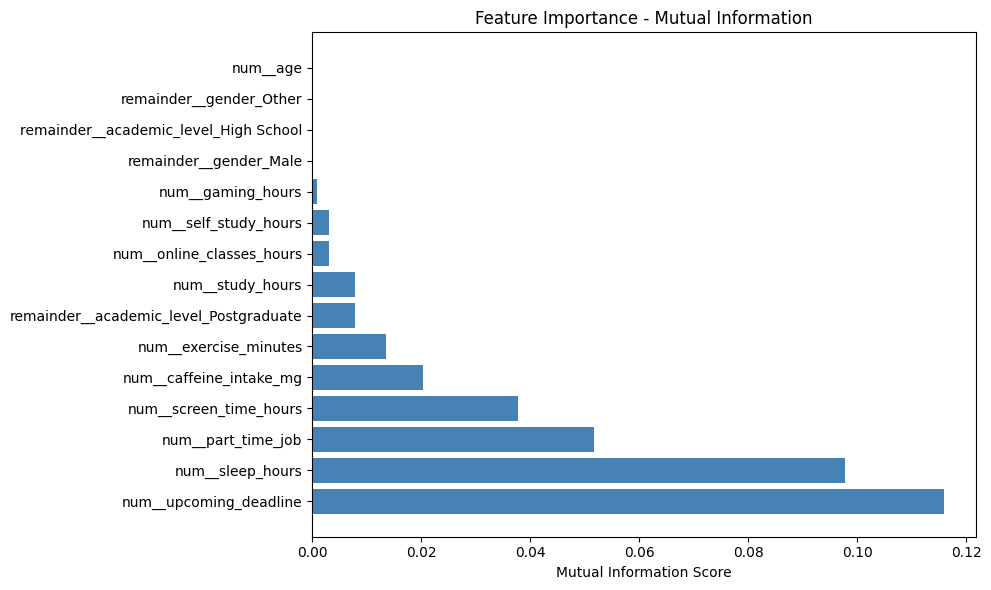


✓ Features selecionadas (MI): 12
  Colunas: ['num__self_study_hours', 'num__online_classes_hours', 'num__social_media_hours', 'num__gaming_hours', 'num__sleep_hours', 'num__screen_time_hours', 'num__exercise_minutes', 'num__caffeine_intake_mg', 'num__part_time_job', 'num__upcoming_deadline', 'remainder__internet_quality', 'remainder__gender_Male']

MÉTODO 2: F-STATISTIC (ANOVA)

Top 15 Features (F-Statistic):
                              feature      score
               num__upcoming_deadline 590.375014
                     num__sleep_hours 465.468585
                   num__part_time_job 239.108118
               num__screen_time_hours 189.518838
              num__caffeine_intake_mg  65.033999
                num__exercise_minutes  36.789853
                num__self_study_hours   2.646875
          remainder__internet_quality   2.456651
               remainder__gender_Male   2.044033
              num__social_media_hours   1.676258
                    num__gaming_hours   1.22824

In [17]:
# Aplicar preprocessador aos dados de classificação
X_learning_clf_processed = preprocessor.transform(X_learning_clf)
X_learning_clf_df = pd.DataFrame(
    X_learning_clf_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_learning_clf.index
)

X_test_clf_processed = preprocessor.transform(X_test_clf)
X_test_clf_df = pd.DataFrame(
    X_test_clf_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_test_clf.index
)

print("\n" + "="*90)
print("MÉTODO 1: MUTUAL INFORMATION")
print("="*90)

mi_scores = mutual_info_classif(X_learning_clf_df, y_burnout_learning, random_state=42)
mi_ranking = pd.DataFrame({
    'feature': X_learning_clf_df.columns,
    'score': mi_scores
}).sort_values('score', ascending=False)

print("\nTop 15 Features (Mutual Information):")
print(mi_ranking.head(15).to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(mi_ranking['feature'].head(15), mi_ranking['score'].head(15), color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance - Mutual Information')
plt.tight_layout()
plt.show()

# SelectKBest com top 12 features
selector_mi = SelectKBest(f_classif, k=12)
X_learning_mi = selector_mi.fit_transform(X_learning_clf_df, y_burnout_learning)
X_learning_mi_df = pd.DataFrame(X_learning_mi, columns=X_learning_clf_df.columns[selector_mi.get_support()])
X_test_mi_df = pd.DataFrame(selector_mi.transform(X_test_clf_df), columns=X_learning_mi_df.columns)

print(f"\n✓ Features selecionadas (MI): {X_learning_mi_df.shape[1]}")
print(f"  Colunas: {list(X_learning_mi_df.columns)}")

print("\n" + "="*90)
print("MÉTODO 2: F-STATISTIC (ANOVA)")
print("="*90)

f_scores = f_classif(X_learning_clf_df, y_burnout_learning)[0]
f_ranking = pd.DataFrame({
    'feature': X_learning_clf_df.columns,
    'score': f_scores
}).sort_values('score', ascending=False)

print("\nTop 15 Features (F-Statistic):")
print(f_ranking.head(15).to_string(index=False))

selector_f = SelectKBest(f_classif, k=12)
X_learning_f = selector_f.fit_transform(X_learning_clf_df, y_burnout_learning)
X_learning_f_df = pd.DataFrame(X_learning_f, columns=X_learning_clf_df.columns[selector_f.get_support()])
X_test_f_df = pd.DataFrame(selector_f.transform(X_test_clf_df), columns=X_learning_f_df.columns)

print(f"\n✓ Features selecionadas (F-Stat): {X_learning_f_df.shape[1]}")
print(f"  Colunas: {list(X_learning_f_df.columns)}")

print("\n" + "="*90)
print("MÉTODO 3: RANDOM FOREST FEATURE IMPORTANCE")
print("="*90)

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_temp.fit(X_learning_clf_df, y_burnout_learning)

rf_ranking = pd.DataFrame({
    'feature': X_learning_clf_df.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features (Random Forest):")
print(rf_ranking.head(15).to_string(index=False))

# Selecionar top 12
top_12_rf = rf_ranking.head(12)['feature'].tolist()
X_learning_rf_df = X_learning_clf_df[top_12_rf]
X_test_rf_df = X_test_clf_df[top_12_rf]

print(f"\n✓ Features selecionadas (RF): {X_learning_rf_df.shape[1]}")
print(f"  Colunas: {list(X_learning_rf_df.columns)}")

print("\n" + "="*90)
print("MÉTODO 4: RECURSIVE FEATURE ELIMINATION (RFE)")
print("="*90)

rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced'),
    n_features_to_select=12,
    step=1
)
X_learning_rfe = rfe.fit_transform(X_learning_clf_df, y_burnout_learning)
X_learning_rfe_df = pd.DataFrame(X_learning_rfe, columns=X_learning_clf_df.columns[rfe.support_])
X_test_rfe_df = pd.DataFrame(rfe.transform(X_test_clf_df), columns=X_learning_rfe_df.columns)

print(f"\n✓ Features selecionadas (RFE): {X_learning_rfe_df.shape[1]}")
print(f"  Colunas: {list(X_learning_rfe_df.columns)}")

print("\n" + "="*90)
print("MÉTODO 5: SEQUENTIAL FEATURE SELECTOR (Forward)")
print("="*90)

sfs_forward = SequentialFeatureSelector(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced'),
    n_features_to_select=12,
    direction='forward',
    cv=5
)
X_learning_sfs = sfs_forward.fit_transform(X_learning_clf_df, y_burnout_learning)
X_learning_sfs_df = pd.DataFrame(X_learning_sfs, columns=X_learning_clf_df.columns[sfs_forward.get_support()])
X_test_sfs_df = pd.DataFrame(sfs_forward.transform(X_test_clf_df), columns=X_learning_sfs_df.columns)

print(f"\n✓ Features selecionadas (SFS Forward): {X_learning_sfs_df.shape[1]}")
print(f"  Colunas: {list(X_learning_sfs_df.columns)}")

print("\n" + "="*90)
print("RESUMO: MÉTODOS DE FEATURE SELECTION")
print("="*90)
print(f"Dataset Original: {X_learning_clf_df.shape[1]} features")
print(f"\nMétodo 1 (MI):           {X_learning_mi_df.shape[1]} features")
print(f"Método 2 (F-Statistic):  {X_learning_f_df.shape[1]} features")
print(f"Método 3 (RF Importance):{X_learning_rf_df.shape[1]} features")
print(f"Método 4 (RFE):          {X_learning_rfe_df.shape[1]} features")
print(f"Método 5 (SFS Forward):  {X_learning_sfs_df.shape[1]} features")
print("="*90)

## 8. Comparação de Modelos com Diferentes Feature Selection Methods

In [8]:
# Definir todos os modelos a testar
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
}

# Definir todos os datasets de feature selection (agora usando dados processados)
feature_selection_methods = {
    'Sem FS (todas)': (X_learning_clf_df, X_test_clf_df),
    'MI': (X_learning_mi_df, X_test_mi_df),
    'F-Statistic': (X_learning_f_df, X_test_f_df),
    'RF Importance': (X_learning_rf_df, X_test_rf_df),
    'RFE': (X_learning_rfe_df, X_test_rfe_df),
    'SFS Forward': (X_learning_sfs_df, X_test_sfs_df),
}

# Matriz de resultados: linhas=modelos, colunas=métodos FS
results_matrix = {}

print("\n" + "="*120)
print("VALIDAÇÃO CRUZADA: COMPARAÇÃO DE MODELOS × FEATURE SELECTION METHODS")
print("="*120)

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fs_name, (X_train_fs, X_test_fs) in feature_selection_methods.items():
    print(f"\n{'='*120}")
    print(f"FEATURE SELECTION: {fs_name} ({X_train_fs.shape[1]} features)")
    print(f"{'='*120}")
    
    results_matrix[fs_name] = {}
    
    for model_name, model in models.items():
        pipe = Pipeline(steps=[('model', model)])
        
        scores = cross_validate(
            pipe,
            X_train_fs,
            y_burnout_learning,
            cv=skfold,
            scoring={'accuracy': 'accuracy', 'f1': 'f1_weighted', 'precision': 'precision_weighted', 'recall': 'recall_weighted'},
            return_train_score=False
        )
        
        acc_mean = scores['test_accuracy'].mean()
        acc_std = scores['test_accuracy'].std()
        f1_mean = scores['test_f1'].mean()
        
        results_matrix[fs_name][model_name] = {
            'accuracy': acc_mean,
            'accuracy_std': acc_std,
            'f1': f1_mean
        }
        
        print(f"{model_name:25} | Accuracy: {acc_mean:.4f} ± {acc_std:.4f} | F1: {f1_mean:.4f}")

print("\n" + "="*120)


VALIDAÇÃO CRUZADA: COMPARAÇÃO DE MODELOS × FEATURE SELECTION METHODS

FEATURE SELECTION: Sem FS (todas) (20 features)
Decision Tree             | Accuracy: 0.6502 ± 0.0073 | F1: 0.6533
Random Forest             | Accuracy: 0.7050 ± 0.0161 | F1: 0.7036
Random Forest             | Accuracy: 0.7050 ± 0.0161 | F1: 0.7036
Gradient Boosting         | Accuracy: 0.7070 ± 0.0133 | F1: 0.7075
Logistic Regression       | Accuracy: 0.7450 ± 0.0080 | F1: 0.7452
Gradient Boosting         | Accuracy: 0.7070 ± 0.0133 | F1: 0.7075
Logistic Regression       | Accuracy: 0.7450 ± 0.0080 | F1: 0.7452
SVM (RBF)                 | Accuracy: 0.7315 ± 0.0103 | F1: 0.7326
KNN (k=5)                 | Accuracy: 0.6352 ± 0.0128 | F1: 0.6351
Naive Bayes               | Accuracy: 0.7132 ± 0.0116 | F1: 0.7160

FEATURE SELECTION: MI (12 features)
Decision Tree             | Accuracy: 0.6525 ± 0.0090 | F1: 0.6551
SVM (RBF)                 | Accuracy: 0.7315 ± 0.0103 | F1: 0.7326
KNN (k=5)                 | Accuracy: 0.

In [ ]:
## 9. Análise e Visualização dos Resultados


MATRIZ DE RESULTADOS: Accuracy Médio (Validação Cruzada)

                     Sem FS (todas)      MI  F-Statistic  RF Importance     RFE  SFS Forward
Decision Tree                0.6502  0.6525       0.6525         0.6510  0.6508       0.6582
Random Forest                0.7050  0.7098       0.7098         0.7155  0.7123       0.7202
Gradient Boosting            0.7070  0.7035       0.7035         0.7015  0.7005       0.7050
Logistic Regression          0.7450  0.7490       0.7490         0.7485  0.7485       0.7475
SVM (RBF)                    0.7315  0.7308       0.7308         0.7330  0.7330       0.7380
KNN (k=5)                    0.6352  0.6605       0.6605         0.6547  0.6547       0.6620
Naive Bayes                  0.7132  0.7215       0.7215         0.7150  0.7150       0.7248

TOP 10 MELHORES COMBINAÇÕES (Model × Feature Selection)

     FS Method               Model  Accuracy       F1    Score
   F-Statistic Logistic Regression    0.7490 0.749549 0.749220
            M

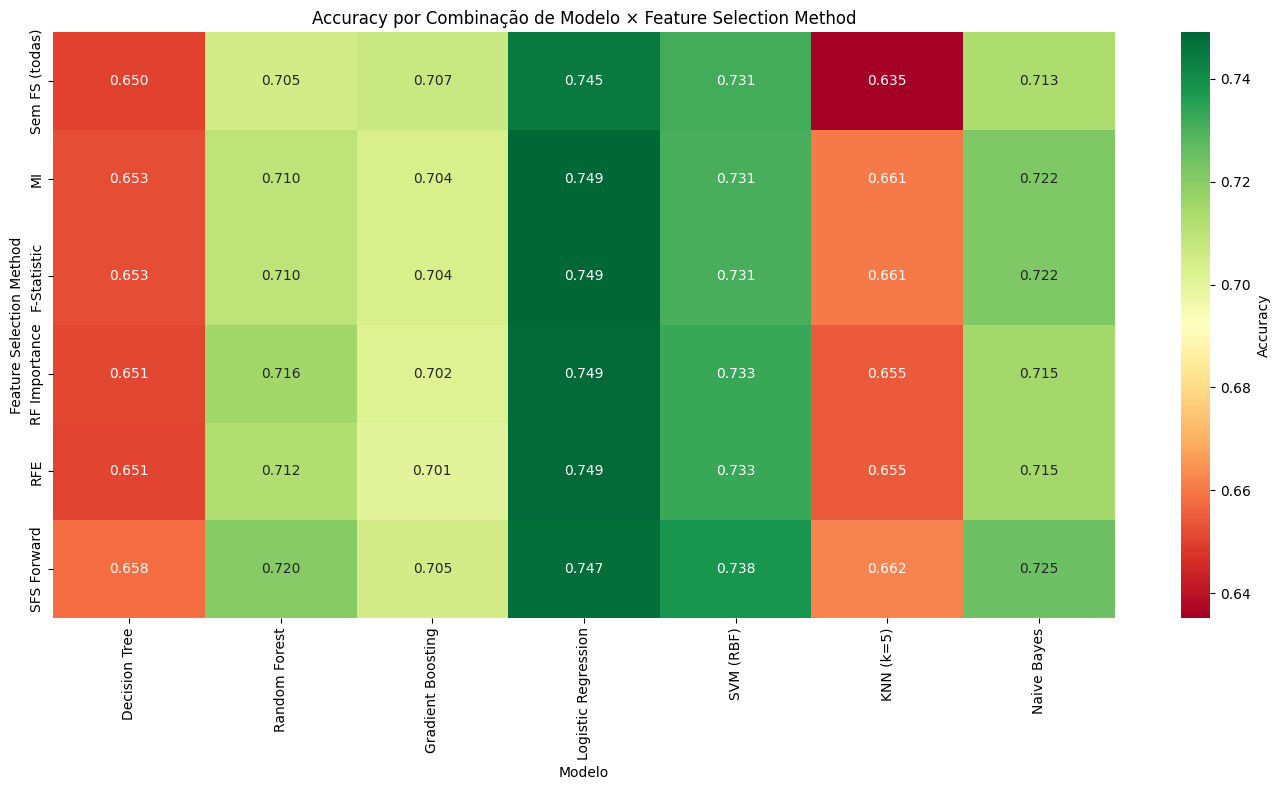

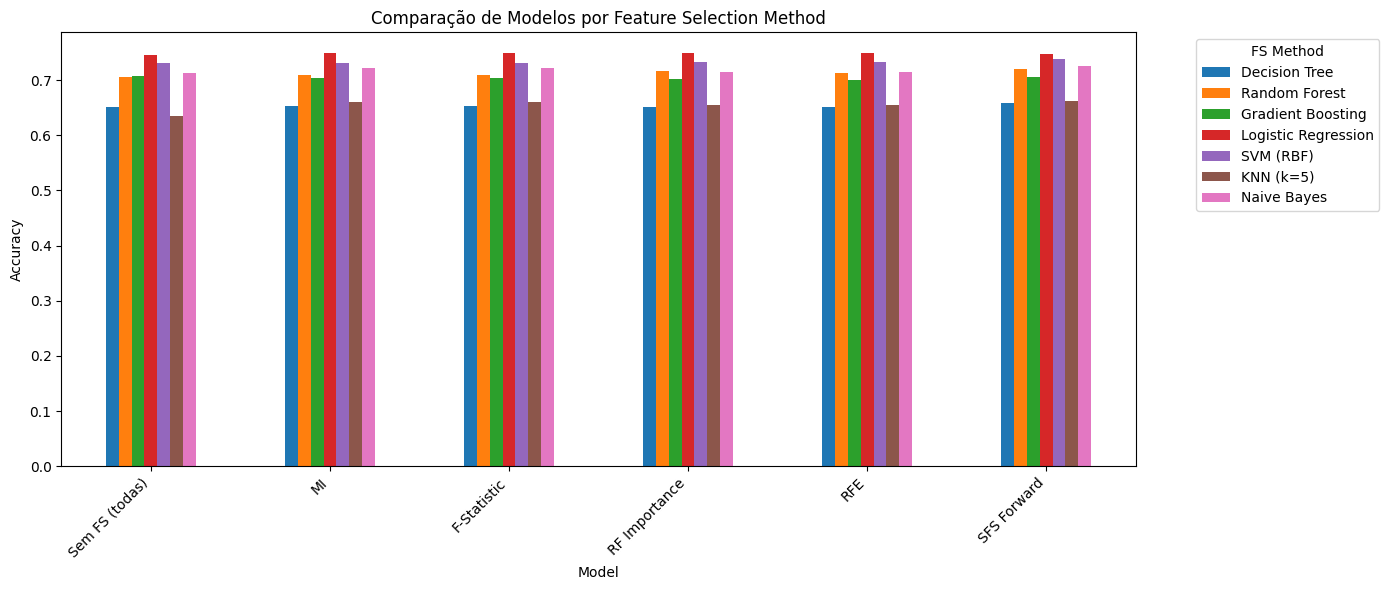

In [9]:
# Criar tabela de resultados em matriz
print("\n" + "="*150)
print("MATRIZ DE RESULTADOS: Accuracy Médio (Validação Cruzada)")
print("="*150)

# Construir DataFrame com resultados
accuracy_matrix = pd.DataFrame(
    {
        fs_method: {
            model_name: results_matrix[fs_method][model_name]['accuracy']
            for model_name in models.keys()
        }
        for fs_method in feature_selection_methods.keys()
    }
)

print("\n" + accuracy_matrix.round(4).to_string())

# Encontrar melhor combinação
print("\n" + "="*150)
print("TOP 10 MELHORES COMBINAÇÕES (Model × Feature Selection)")
print("="*150)

best_combinations = []
for fs_method in feature_selection_methods.keys():
    for model_name in models.keys():
        acc = results_matrix[fs_method][model_name]['accuracy']
        f1 = results_matrix[fs_method][model_name]['f1']
        best_combinations.append({
            'FS Method': fs_method,
            'Model': model_name,
            'Accuracy': acc,
            'F1': f1,
            'Score': acc * 0.6 + f1 * 0.4  # Weighted score
        })

best_df = pd.DataFrame(best_combinations).sort_values('Score', ascending=False)
print("\n" + best_df.head(10).to_string(index=False))

# Selecionar a melhor combinação
best_fs_method = best_df.iloc[0]['FS Method']
best_model_name = best_df.iloc[0]['Model']
best_accuracy = best_df.iloc[0]['Accuracy']
best_f1 = best_df.iloc[0]['F1']

print("\n" + "="*150)
print("🎯 MELHOR COMBINAÇÃO")
print("="*150)
print(f"Feature Selection: {best_fs_method}")
print(f"Modelo: {best_model_name}")
print(f"Accuracy (CV): {best_accuracy:.4f}")
print(f"F1-Score (CV): {best_f1:.4f}")
print("="*150)

# Visualizar matriz de resultados
plt.figure(figsize=(14, 8))
sns.heatmap(accuracy_matrix.T, annot=True, fmt='.3f', cmap='RdYlGn', cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy por Combinação de Modelo × Feature Selection Method')
plt.xlabel('Modelo')
plt.ylabel('Feature Selection Method')
plt.tight_layout()
plt.show()

# Gráfico comparativo por FS Method
fig, ax = plt.subplots(figsize=(14, 6))
accuracy_matrix.T.plot(kind='bar', ax=ax)
plt.title('Comparação de Modelos por Feature Selection Method')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.legend(title='FS Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## 9B. Tabela Comparativa Completa: Modelos × Feature Selection com Todas as Métricas

# Construir tabela completa com todas as métricas (accuracy, precision, recall, f1, roc_auc)
print("\n" + "="*180)
print("TABELA COMPARATIVA COMPLETA: Modelos × Feature Selection Methods")
print("Métricas: n_features, accuracy, precision, recall, f1, roc_auc")
print("="*180)

comparison_data = []

for fs_method in feature_selection_methods.keys():
    X_train_fs, X_test_fs = feature_selection_methods[fs_method]
    n_features = X_train_fs.shape[1]
    
    for model_name, model in models.items():
        # Treinar modelo
        model.fit(X_train_fs, y_burnout_learning)
        
        # Prever no test set
        y_pred = model.predict(X_test_fs)
        
        # Calcular todas as métricas
        acc = accuracy_score(y_burnout_test, y_pred)
        prec = precision_score(y_burnout_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_burnout_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_burnout_test, y_pred, average='weighted', zero_division=0)
        
        # Calcular ROC-AUC (one-vs-rest para multiclass)
        try:
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test_fs)
                from sklearn.metrics import roc_auc_score
                roc = roc_auc_score(y_burnout_test, y_pred_proba, multi_class='ovr', zero_division=0)
            else:
                roc = np.nan
        except:
            roc = np.nan
        
        comparison_data.append({
            'Feature Selection': fs_method,
            'Model': model_name,
            'n_features': n_features,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': roc
        })

# Criar DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Ordenar por score ponderado (60% accuracy + 40% f1) descendente
comparison_df['weighted_score'] = comparison_df['accuracy'] * 0.6 + comparison_df['f1'] * 0.4
comparison_df_sorted = comparison_df.sort_values('weighted_score', ascending=False)

# Exibir tabela formatada
print("\n" + comparison_df_sorted[['Feature Selection', 'Model', 'n_features', 'accuracy', 
                                   'precision', 'recall', 'f1', 'roc_auc']].to_string(index=False))

print("\n" + "="*180)
print("\nTop 15 Melhores Combinações (ordenadas por Score Ponderado: 60% Accuracy + 40% F1):")
print("="*180)

top_15 = comparison_df_sorted.head(15)[['Feature Selection', 'Model', 'n_features', 'accuracy', 
                                         'precision', 'recall', 'f1', 'roc_auc', 'weighted_score']]
print("\n" + top_15.to_string(index=False))

# Criar tabela resumida (similar ao formato pedido)
print("\n" + "="*180)
print("\nRESUMO TABULAR: FS Method | Accuracy | Precision | Recall | F1 | ROC-AUC (melhor modelo por FS)")
print("="*180)

summary_by_fs = []
for fs_method in feature_selection_methods.keys():
    fs_data = comparison_df[comparison_df['Feature Selection'] == fs_method]
    best_for_fs = fs_data.loc[fs_data['accuracy'].idxmax()]
    
    summary_by_fs.append({
        'Feature Selection': fs_method,
        'Best Model': best_for_fs['Model'],
        'n_features': int(best_for_fs['n_features']),
        'accuracy': best_for_fs['accuracy'],
        'precision': best_for_fs['precision'],
        'recall': best_for_fs['recall'],
        'f1': best_for_fs['f1'],
        'roc_auc': best_for_fs['roc_auc']
    })

summary_df = pd.DataFrame(summary_by_fs)
summary_df_sorted = summary_df.sort_values('accuracy', ascending=False)

print("\n" + summary_df_sorted.to_string(index=False))

# Visualizar heatmap de accuracy para todas as combinações
print("\n" + "="*180)
print("Gerando visualizações...")
print("="*180)

# Heatmap de Accuracy
pivot_accuracy = comparison_df.pivot_table(values='accuracy', 
                                           index='Model', 
                                           columns='Feature Selection')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_accuracy, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy: Todos os Modelos × Todos os Feature Selection Methods')
plt.xlabel('Feature Selection Method')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Heatmap de F1-Score
pivot_f1 = comparison_df.pivot_table(values='f1', 
                                     index='Model', 
                                     columns='Feature Selection')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score: Todos os Modelos × Todos os Feature Selection Methods')
plt.xlabel('Feature Selection Method')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Heatmap de ROC-AUC
pivot_roc = comparison_df.pivot_table(values='roc_auc', 
                                      index='Model', 
                                      columns='Feature Selection')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_roc, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'ROC-AUC'})
plt.title('ROC-AUC: Todos os Modelos × Todos os Feature Selection Methods')
plt.xlabel('Feature Selection Method')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Gráfico de barras comparativo por métrica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'weighted_score']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    best_by_fs = comparison_df.loc[comparison_df.groupby('Feature Selection')[metric].idxmax()]
    best_by_fs_sorted = best_by_fs.sort_values(metric, ascending=False)
    
    colors = ['green' if i == 0 else 'steelblue' for i in range(len(best_by_fs_sorted))]
    ax.barh(range(len(best_by_fs_sorted)), best_by_fs_sorted[metric], color=colors)
    ax.set_yticks(range(len(best_by_fs_sorted)))
    ax.set_yticklabels(best_by_fs_sorted['Feature Selection'])
    ax.set_xlabel(metric.upper())
    ax.set_title(f'Melhor Modelo por FS - {metric.upper()}')
    ax.set_xlim([0.8, 1.0])
    
    # Adicionar valores nas barras
    for i, v in enumerate(best_by_fs_sorted[metric]):
        ax.text(v - 0.02, i, f'{v:.4f}', va='center', ha='right', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n" + "="*180)
print("✅ Tabela Comparativa Completa Gerada com Sucesso!")
print("="*180)

## 10. Avaliação Final no Test Set - Melhor Modelo Selecionado

In [10]:
# Obter os dados com o melhor método de FS
X_train_best, X_test_best = feature_selection_methods[best_fs_method]

# Obter o melhor modelo
best_model = models[best_model_name]

print("\n" + "="*80)
print("TREINAMENTO E AVALIAÇÃO NO TEST SET")
print("="*80)
print(f"Feature Selection Method: {best_fs_method}")
print(f"Dataset Shape: {X_train_best.shape[0]} × {X_train_best.shape[1]} (treino)")
print(f"Model: {best_model_name}")
print("="*80)

# Treinar o modelo com os dados do learning set
best_model.fit(X_train_best, y_burnout_learning)

# Fazer predições no test set
y_burnout_pred_best = best_model.predict(X_test_best)

# Calcular métricas
accuracy_best = accuracy_score(y_burnout_test, y_burnout_pred_best)
precision_best = precision_score(y_burnout_test, y_burnout_pred_best, average='weighted', zero_division=0)
recall_best = recall_score(y_burnout_test, y_burnout_pred_best, average='weighted', zero_division=0)
f1_best = f1_score(y_burnout_test, y_burnout_pred_best, average='weighted', zero_division=0)

print(f"\n{best_model_name} - RESULTADOS NO TEST SET:")
print(f"  Accuracy:  {accuracy_best:.4f}")
print(f"  Precision: {precision_best:.4f}")
print(f"  Recall:    {recall_best:.4f}")
print(f"  F1-Score:  {f1_best:.4f}")

# Agora vamos comparar com o baseline (Decision Tree simples)
# Precisamos retreinar o modelo baseline para comparação
best_clf_baseline = DecisionTreeClassifier(max_depth=best_depth_clf, random_state=42)
best_clf_baseline.fit(X_learning_clf, y_burnout_learning)
y_burnout_pred_baseline = best_clf_baseline.predict(X_test_clf)
accuracy_clf_baseline = accuracy_score(y_burnout_test, y_burnout_pred_baseline)

print("\n" + "="*80)
print("COMPARAÇÃO: BASELINE vs OTIMIZADO")
print("="*80)
print(f"Decision Tree (Baseline):           {accuracy_clf_baseline:.4f}")
print(f"{best_model_name} ({best_fs_method}): {accuracy_best:.4f}")
print(f"Melhoria:                           {(accuracy_best - accuracy_clf_baseline):+.4f} ({((accuracy_best - accuracy_clf_baseline)/accuracy_clf_baseline * 100):+.1f}%)")
print("="*80)

# Matriz de confusão
cm = confusion_matrix(y_burnout_test, y_burnout_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {best_model_name} ({best_fs_method})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_burnout_test, y_burnout_pred_best, 
                          target_names=['Baixo', 'Médio', 'Alto'], 
                          zero_division=0))


TREINAMENTO E AVALIAÇÃO NO TEST SET
Feature Selection Method: F-Statistic
Dataset Shape: 4000 × 12 (treino)
Model: Logistic Regression

Logistic Regression - RESULTADOS NO TEST SET:
  Accuracy:  0.7440
  Precision: 0.7452
  Recall:    0.7440
  F1-Score:  0.7446


NameError: name 'best_depth_clf' is not defined

---

# PARTE 2: REGRESSÃO - Prever Exam Score (Nota Máxima)

## 5. Model Selection: Regressão com Validação Cruzada

In [ ]:
# Realizar validação cruzada 5-fold no learning set para regressão
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Regressão Linear para Exam Score com dados JÁ PROCESSADOS (X_learning)
pipe_reg = Pipeline(steps=[('model', LinearRegression())])
scores_reg = cross_validate(pipe_reg, X_learning, y_exam_learning, cv=kfold,
                            scoring=['neg_mean_absolute_error', 'r2'],
                            return_train_score=True)

print("Resultados da Validação Cruzada (Regressão):")
print(f"MAE (validation): {-scores_reg['test_neg_mean_absolute_error'].mean():.3f} (±{scores_reg['test_neg_mean_absolute_error'].std():.3f})")
print(f"R² (validation):  {scores_reg['test_r2'].mean():.3f} (±{scores_reg['test_r2'].std():.3f})")

Resultados da Validação Cruzada (Regressão):
MAE (validation): 5.353 (±0.128)
R² (validation):  0.691 (±0.022)


## 6. Avaliação Final no Test Set (Regressão)

In [ ]:
# Retreinar o melhor modelo de regressão no learning set completo com dados JÁ PROCESSADOS
print("="*70)
print("AVALIAÇÃO FINAL - REGRESSÃO (Exam Score)")
print("="*70)

pipe_reg_final = Pipeline(steps=[('model', LinearRegression())])

# Treinar com dados já processados (X_learning)
print("\nTreinando modelo com Learning Set...")
pipe_reg_final.fit(X_learning, y_exam_learning)

# Prever no test set com dados já processados (X_test)
print("Fazendo predições no Test Set...")
y_exam_pred = pipe_reg_final.predict(X_test)

# Calcular métricas
mae_reg = mean_absolute_error(y_exam_test, y_exam_pred)
rmse_reg = np.sqrt(((y_exam_test - y_exam_pred)**2).mean())
r2_reg = r2_score(y_exam_test, y_exam_pred)

print("\n" + "="*70)
print("RESULTADOS - REGRESSÃO (Test Set)")
print("="*70)

print(f"\nLinear Regression - Prever Exam Score (Nota Máxima)")
print(f"MAE (Mean Absolute Error): {mae_reg:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_reg:.4f}")
print(f"R² Score: {r2_reg:.4f}")

print("\n" + "="*70)

# Resumo final
print("\n" + "="*70)
print("RESUMO FINAL DOS MODELOS")
print("="*70)
print(f"\n1. CLASSIFICAÇÃO (Burnout Level):")
print(f"   - Modelo: Decision Tree (max_depth={best_depth_clf})")
print(f"   - Accuracy: {accuracy_clf:.4f}")
print(f"   - Precision: {precision_clf:.4f}")
print(f"   - Recall: {recall_clf:.4f}")
print(f"   - F1-Score: {f1_clf:.4f}")
print(f"\n2. REGRESSÃO (Exam Score):")
print(f"   - Modelo: Linear Regression")
print(f"   - R² Score: {r2_reg:.4f}")
print(f"   - MAE: {mae_reg:.4f}")
print(f"   - RMSE: {rmse_reg:.4f}")
print("\n" + "="*70)

RESULTADOS - REGRESSÃO (Test Set)

Linear Regression - Prever Exam Score (Nota Máxima)
MAE (Mean Absolute Error): 5.459
RMSE (Root Mean Squared Error): 6.855
R² Score: 0.655


RESUMO FINAL DOS MODELOS

1. CLASSIFICAÇÃO (Burnout Level):
   - Modelo: Decision Tree (max_depth=5)
   - Accuracy: 0.672
   - F1-Score: 0.672

2. REGRESSÃO (Exam Score):
   - Modelo: Linear Regression
   - R² Score: 0.655
   - MAE: 5.459

